# Neural Networks for Binary Classification: Diabetes Diagnosis

Loading the required libraries 

In [3]:
# Set random seeds for reproducible results
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Data processing and visualization
import numpy as np                           # Numerical computing
import pandas as pd                          # Data manipulation
from sklearn.datasets import load_breast_cancer  # Load biomedical dataset
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.preprocessing import StandardScaler    # Scale features (normalize values)
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score  # Evaluation metrics

# Deep learning
from tensorflow.keras import models, layers  # Build neural network
from tensorflow.keras.optimizers import Adam  # Optimizer for training
from tensorflow.keras.callbacks import EarlyStopping  # Stop training when validation loss plateaus

# Visualization
import matplotlib.pyplot as plt              # Plot training curves and results
import seaborn as sns                        # Enhanced visualizations

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


Load the Diabetes dataset from kaggle

In [4]:

data= pd.read_csv('diabetes.csv')

print(data.head())

# Remove rows with missing values
data = data.dropna()

print(f"Dataset downloaded successfully!")
print(f"Total samples after removing missing values: {data.shape[0]}")

X = data.drop('Outcome', axis=1).values
y = data['Outcome'].values 

# Optional: Get feature names for reference
feature_names = data.columns[:-1].tolist()
target_names = np.array(['No Diabetes', 'Diabetes'])

print(f"\nFeatures shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Feature names: {feature_names}")

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Dataset downloaded successfully!
Total samples after removing missing values: 768

Features shape: (768, 8)
Labels shape: (768,)
Feature names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


Explore the dataset structure

In [5]:

print("=" * 70)
print("PIMA INDIANS DIABETES DATASET EXPLORATION")
print("=" * 70)

print(f"\nTotal samples: {X.shape[0]}")
print(f"Total features: {X.shape[1]}")

print(f"\nFeatures represent clinical measurements:")
print(f"  • Pregnancies")
print(f"  • Glucose")
print(f"  • Blood Pressure")
print(f"  • Skin Thickness")
print(f"  • Insulin")
print(f"  • BMI")
print(f"  • Diabetes Pedigree Function")
print(f"  • Age")

print(f"\nClass Distribution:")
print(f"  No Diabetes (0): {np.sum(y == 0)} samples ({100*np.sum(y==0)/len(y):.1f}%)")
print(f"  Diabetes (1): {np.sum(y == 1)} samples ({100*np.sum(y==1)/len(y):.1f}%)")

print(f"\nFeature Value Ranges:")
print(f"  Min values: {X.min(axis=0)[:5]}")
print(f"  Max values: {X.max(axis=0)[:5]}")

print(f"\nFirst 5 patients (first 5 features):")
print(f"  Preg | Gluc | BP | Skin | Insul")
for i in range(5):
    print(f"  {X[i, 0]:.0f}    | {X[i, 1]:.0f}  | {X[i, 2]:.0f} | {X[i, 3]:.0f}   | {X[i, 4]:.0f}")

PIMA INDIANS DIABETES DATASET EXPLORATION

Total samples: 768
Total features: 8

Features represent clinical measurements:
  • Pregnancies
  • Glucose
  • Blood Pressure
  • Skin Thickness
  • Insulin
  • BMI
  • Diabetes Pedigree Function
  • Age

Class Distribution:
  No Diabetes (0): 500 samples (65.1%)
  Diabetes (1): 268 samples (34.9%)

Feature Value Ranges:
  Min values: [0. 0. 0. 0. 0.]
  Max values: [ 17. 199. 122.  99. 846.]

First 5 patients (first 5 features):
  Preg | Gluc | BP | Skin | Insul
  6    | 148  | 72 | 35   | 0
  1    | 85  | 66 | 29   | 0
  8    | 183  | 64 | 0   | 0
  1    | 89  | 66 | 23   | 94
  0    | 137  | 40 | 35   | 168


## 2. Data Preprocessing

In [6]:
# Step 1: Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,          
    random_state=42,       
    stratify=y               
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print(f"\nTraining set class distribution:")

print(f"  No Diabetes (0): {np.sum(y_train == 0)} ({100*np.sum(y_train==0)/len(y_train):.1f}%)")
print(f"  Diabetes (1):    {np.sum(y_train == 1)} ({100*np.sum(y_train==1)/len(y_train):.1f}%)")

print(f"\nBefore Scaling - Feature Statistics (First 3 features):")
# This shows how "messy" the raw numbers are before we fix them
print(f"  Mean: {X_train.mean(axis=0)[:3]}")
print(f"  Std Dev: {X_train.std(axis=0)[:3]}")

Training set size: 614 samples
Testing set size: 154 samples

Training set class distribution:
  No Diabetes (0): 400 (65.1%)
  Diabetes (1):    214 (34.9%)

Before Scaling - Feature Statistics (First 3 features):
  Mean: [  3.81921824 120.90879479  69.44299674]
  Std Dev: [ 3.31144822 31.53538141 18.38758897]


In [7]:

# Initialize the scaler
scaler = StandardScaler()

# Fit only on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler (do not refit!)
X_test_scaled = scaler.transform(X_test)

print("After Scaling - Feature Statistics:")
print(f"  Training mean: {X_train_scaled.mean(axis=0)[:3]} (should be ~0)")
print(f"  Training std dev: {X_train_scaled.std(axis=0)[:3]} (should be ~1)")
print(f"  Test mean: {X_test_scaled.mean(axis=0)[:3]} (close to 0)")
print(f"  Test std dev: {X_test_scaled.std(axis=0)[:3]} (close to 1)")

print("✓ Data scaling complete!")

After Scaling - Feature Statistics:
  Training mean: [-1.87146715e-17  1.64725273e-16 -1.92752076e-16] (should be ~0)
  Training std dev: [1. 1. 1.] (should be ~1)
  Test mean: [ 0.03890555 -0.00225564 -0.09154308] (close to 0)
  Test std dev: [1.08105932 1.06422238 1.23495961] (close to 1)
✓ Data scaling complete!


## 3. Build Neural Network

In [8]:
# Step 3: Build the Neural Network Architecture
model = models.Sequential([
    # Input layer: 8 neurons for the 8 features in the Pima dataset
    # Hidden layer 1: 32 neurons with ReLU activation
    layers.Dense(32, activation='relu', input_shape=(8,)), 
    
    # Hidden layer 2: 16 neurons
    layers.Dense(16, activation='relu'), 
    
    # Output layer: 1 neuron with Sigmoid (outputs a probability between 0 and 1)
    layers.Dense(1, activation='sigmoid') 
])

# View the structure
model.summary()

c:\Users\Pavilion\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile Model

In [9]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),        # Adaptive optimizer
    loss='binary_crossentropy',                 # For binary classification
    metrics=['binary_accuracy']                 # Track accuracy during training
)

print("✓ Model compiled successfully!")

✓ Model compiled successfully!


## 5. Train Model with Early Stopping


In [10]:
# Set up Early Stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',                      # Watch validation loss
    patience=5,                              # Stop if no improvement for 5 epochs (aggressive)
    restore_best_weights=True,               # Return to best weights
    verbose=1
)

# Train the model with Early Stopping
print("Starting training with Early Stopping...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,                              # Max epochs (may stop early)
    batch_size=32,                           # Samples per gradient update
    validation_split=0.2,                    # Use 20% of training data for validation
    callbacks=[early_stop],                  # Apply early stopping
    verbose=1                                # Show progress bar
)

print("\n✓ Training complete! Model stopped at best validation performance.")

Starting training with Early Stopping...
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - binary_accuracy: 0.4949 - loss: 0.7146 - val_binary_accuracy: 0.6667 - val_loss: 0.6683
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6640 - loss: 0.6507 - val_binary_accuracy: 0.7236 - val_loss: 0.6187
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.7108 - loss: 0.6074 - val_binary_accuracy: 0.7398 - val_loss: 0.5810
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7332 - loss: 0.5744 - val_binary_accuracy: 0.7724 - val_loss: 0.5492
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.7454 - loss: 0.5474 - val_binary_accuracy: 0.7805 - val_loss: 0.5229
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.7617 - loss: 0.5245 - val_binary_accuracy: 0.7724 - val_loss: 0.5009
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.7719 - loss: 0.5055 - val_binary_accurac

# Training Curves

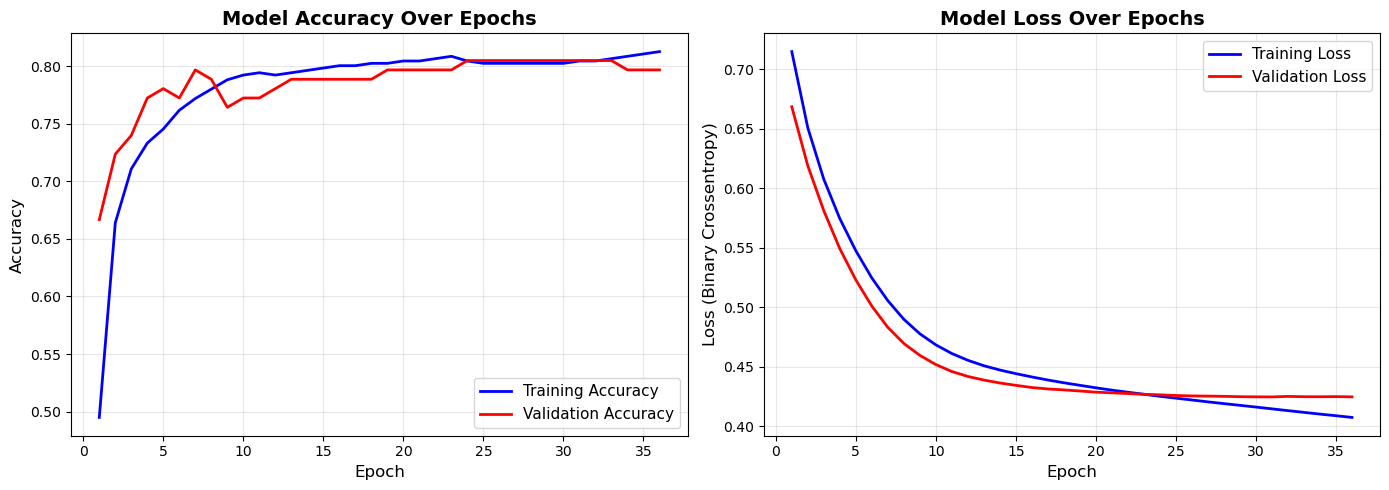

✓ Training visualization complete!


In [11]:
# Extract history data
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']
accuracy_values = history.history['binary_accuracy']
val_accuracy_values = history.history['val_binary_accuracy']

epochs = range(1, len(loss_values) + 1)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy
ax1.plot(epochs, accuracy_values, 'b-', label='Training Accuracy', linewidth=2)
ax1.plot(epochs, val_accuracy_values, 'r-', label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
# ax1.set_ylim([0.8, 1.0])  # Removed: was hiding validation accuracy below 0.8

# Plot 2: Loss
ax2.plot(epochs, loss_values, 'b-', label='Training Loss', linewidth=2)
ax2.plot(epochs, val_loss_values, 'r-', label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training visualization complete!")

## 6. Evaluate Model

In [12]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("=" * 70)
print("MODEL EVALUATION ON TEST DATA")
print("=" * 70)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\n✓ Model successfully evaluated on unseen test data!")

MODEL EVALUATION ON TEST DATA

Test Loss: 0.4835
Test Accuracy: 0.7338 (73.38%)

✓ Model successfully evaluated on unseen test data!


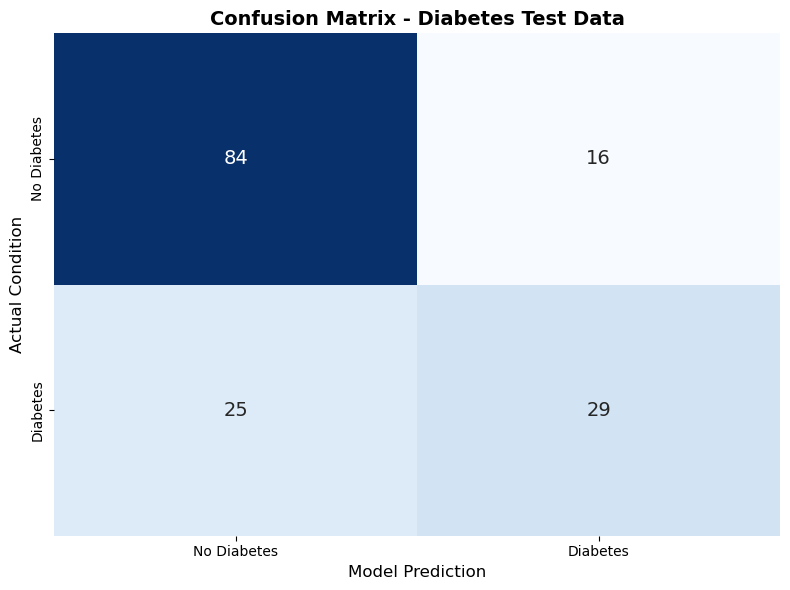


Confusion Matrix Analysis:
  True Negatives (TN):  84  (Correctly identified as Healthy)
  False Positives (FP): 16  (Healthy patient predicted as Diabetic)
  False Negatives (FN): 25  (Diabetic patient predicted as Healthy)
  True Positives (TP):  29  (Correctly identified as Diabetic)


In [14]:
# Make predictions on test data
y_pred_prob = model.predict(X_test_scaled, verbose=0)  # Get probabilities
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert to class labels (0 or 1)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix - Diabetes Test Data', fontsize=14, fontweight='bold')
plt.ylabel('Actual Condition', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)
plt.tight_layout()

plt.show()

print("\nConfusion Matrix Analysis:")
print(f"  True Negatives (TN):  {cm[0, 0]}  (Correctly identified as Healthy)")
print(f"  False Positives (FP): {cm[0, 1]}  (Healthy patient predicted as Diabetic)")
print(f"  False Negatives (FN): {cm[1, 0]}  (Diabetic patient predicted as Healthy)")
print(f"  True Positives (TP):  {cm[1, 1]}  (Correctly identified as Diabetic)")

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate additional metrics
# In the diabetes dataset, '1' is the positive class (Diabetes)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate metrics for the 'No Diabetes' class (0)
precision_no_diabetes = precision_score(y_test, y_pred, pos_label=0)
recall_no_diabetes = recall_score(y_test, y_pred, pos_label=0)

print("=" * 70)
print("DETAILED CLASSIFICATION METRICS - DIABETES")
print("=" * 70)

print(f"\nOverall Metrics (Positive Class: Diabetes):")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {precision:.4f} (of predicted Diabetes, {precision*100:.2f}% are correct)")
print(f"  Recall:    {recall:.4f} (we catch {recall*100:.2f}% of actual Diabetes cases)")
print(f"  F1-Score:  {f1:.4f} (harmonic mean)")

print(f"\nHealthy (Class 0) Identification:")
print(f"  Recall:    {recall_no_diabetes:.4f} (catch {recall_no_diabetes*100:.2f}% of healthy cases)")
print(f"  Precision: {precision_no_diabetes:.4f}")

print(f"\n📊 Medical Interpretation:")
print(f"  • False Negatives: {cm[1, 0]} cases (Actually Diabetic but predicted as Healthy) ⚠️")
print(f"  • False Positives: {cm[0, 1]} cases (Actually Healthy but predicted as Diabetic)")
print(f"  • For medical diagnosis: High Recall is critical to avoid missing sick patients!")

DETAILED CLASSIFICATION METRICS - DIABETES

Overall Metrics (Positive Class: Diabetes):
  Accuracy:  0.7338
  Precision: 0.6444 (of predicted Diabetes, 64.44% are correct)
  Recall:    0.5370 (we catch 53.70% of actual Diabetes cases)
  F1-Score:  0.5859 (harmonic mean)

Healthy (Class 0) Identification:
  Recall:    0.8400 (catch 84.00% of healthy cases)
  Precision: 0.7706

📊 Medical Interpretation:
  • False Negatives: 25 cases (Actually Diabetic but predicted as Healthy) ⚠️
  • False Positives: 16 cases (Actually Healthy but predicted as Diabetic)
  • For medical diagnosis: High Recall is critical to avoid missing sick patients!
